## Set up your Python environment

EzTaoX requires Python >=3.9,<3.13. 

To create a virtual environment with conda, please follow the next steps:
```bash
conda create -n eztaox python=3.12
conda activate eztaox
pip install eztaox lsdb jupyter matplotlib
python -m ipykernel install --user --name eztaox --display-name "EzTaoX (Python 3.12)"
```

You should now be able to select the EzTaoX kernel from your Jupyter notebook.

In [1]:
import lsdb
import matplotlib.pyplot as plt
import numpy as np
import pyarrow as pa

from dask.distributed import Client
from nested_pandas import NestedDtype

### Load DP1 DIA objects

In [2]:
dia_object_cat = lsdb.open_catalog(
    "/rubin/lsdb_data/dia_object_collection",
    columns=["ra", "dec", "diaObjectId", "nDiaSources", "diaObjectForcedSource"],
    filters=[["nDiaSources", ">", 10]],
)
print(f"Number of DIA objects in DP1: {len(dia_object_cat):,}")

Number of DIA objects in DP1: 1,089,818


### Remove objects with flags

In [3]:
# Remove all objects which have at least one of the flags set
flag_subcols = [
    c for c in dia_object_cat["diaObjectForcedSource"].columns if "flag" in c.lower()
]
dia_object_cat = dia_object_cat.query(
    " and ".join([f"diaObjectForcedSource.{c} != 1" for c in flag_subcols])
)

### Remove NA values

- Remove all forced sources with NA mjds/mags.
- Remove all objects with no forced sources.

In [4]:
def remove_na_sources(df):
    subcols = [
        f"diaObjectForcedSource.{subcol}"
        for subcol in ["midpointMjdTai", "psfMag", "psfMagErr"]
    ]
    return df.dropna(subset=subcols).dropna(subset="diaObjectForcedSource")


dia_object_cat = dia_object_cat.map_partitions(remove_na_sources)
dia_object_cat

,ra,dec,diaObjectId,nDiaSources,diaObjectForcedSource
npartitions=208,,,,,
"Order: 6, Pixel: 130",double[pyarrow],double[pyarrow],int64[pyarrow],int64[pyarrow],"nested<parentObjectId: [int64], coord_ra: [dou..."
"Order: 6, Pixel: 136",...,...,...,...,...
...,...,...,...,...,...
"Order: 11, Pixel: 36833621",...,...,...,...,...
"Order: 7, Pixel: 143884",...,...,...,...,...


### Clean up light curves

Remove outliers, bin by day and combine magnitudes.

In [5]:
def _remove_outliers(
    time_band: np.ndarray,
    mag_band: np.ndarray,
    magerr_band: np.ndarray,
    outlier_snr: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Remove data points beyond outlier_snr standard deviations from the mean."""
    if len(time_band) <= 1 or np.nanstd(mag_band) == 0:
        return time_band, mag_band, magerr_band

    sigma = np.abs(mag_band - np.nanmean(mag_band)) / np.nanstd(mag_band)
    mask = sigma < outlier_snr
    return time_band[mask], mag_band[mask], magerr_band[mask]


def _bin_band(
    time_band: np.ndarray,
    mag_band: np.ndarray,
    magerr_band: np.ndarray,
    band_label: str,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Bin observations by epoch (rounded to nearest day) and combine magnitudes."""
    rounded_times = np.round(time_band)
    unique_epochs = np.unique(rounded_times)

    binned_times, binned_mags, binned_magerrs = [], [], []
    for epoch in unique_epochs:
        epoch_mask = rounded_times == epoch
        tmp_mag, tmp_err = _combine_mag(mag_band[epoch_mask], magerr_band[epoch_mask])
        binned_times.append(epoch)
        binned_mags.append(tmp_mag)
        binned_magerrs.append(tmp_err)

    binned_bands = np.full(len(unique_epochs), band_label)
    return (
        np.array(binned_times),
        binned_bands,
        np.array(binned_mags),
        np.array(binned_magerrs),
    )


def _combine_mag(mag, mag_err):
    ## add in quaduature mean(magerr) and std(mag) in each epoch
    ## e.g., https://arxiv.org/abs/2411.06617
    mag = np.asarray(mag)
    mag_err = np.asarray(mag_err)
    mag_w = np.nanmean(mag)
    mag_w_err = np.sqrt(np.nanmean(mag_err) ** 2 + np.nanstd(mag) ** 2)
    return mag_w, mag_w_err


def clean_lightcurves(
    time: np.ndarray,
    band: np.ndarray,
    mag: np.ndarray,
    magerr: np.ndarray,
    outlier_snr: float = 10.0,
    binning: bool = True,
) -> dict[str, np.ndarray]:
    """
    Clean light curves by removing outliers and optionally binning by epoch.

    Args:
        time:        Timestamps (MJD).
        band:        Band labels.
        mag:         Magnitudes.
        magerr:      Magnitude errors.
        outlier_snr: Sigma threshold for outlier rejection.
        binning:     If True, combine observations within the same epoch.

    Returns:
        Dictionary with cleaned times, bands, magnitudes, and magnitude errors,
        sorted by time.
    """
    times, bands, mags, magerrs = [], [], [], []

    for b in np.unique(band):
        band_mask = band == b
        time_band, mag_band, magerr_band = (
            time[band_mask],
            mag[band_mask],
            magerr[band_mask],
        )

        time_band, mag_band, magerr_band = _remove_outliers(
            time_band, mag_band, magerr_band, outlier_snr
        )

        if binning:
            t, b_arr, m, me = _bin_band(time_band, mag_band, magerr_band, b)
        else:
            t, b_arr, m, me = (
                time_band,
                np.full(len(time_band), b),
                mag_band,
                magerr_band,
            )

        times.append(t)
        bands.append(b_arr)
        mags.append(m)
        magerrs.append(me)

    times, bands, mags, magerrs = (
        np.concatenate(times),
        np.concatenate(bands),
        np.concatenate(mags),
        np.concatenate(magerrs),
    )

    ind_sort = np.argsort(times)
    return {
        "cleanLC.Mjd": times[ind_sort],
        "cleanLC.Band": bands[ind_sort],
        "cleanLC.Mag": mags[ind_sort],
        "cleanLC.MagErr": magerrs[ind_sort],
    }

Process all light curves in parallel:

In [6]:
result = dia_object_cat.map_rows(
    clean_lightcurves,
    columns=[
        "diaObjectForcedSource.midpointMjdTai",
        "diaObjectForcedSource.band",
        "diaObjectForcedSource.psfMag",
        "diaObjectForcedSource.psfMagErr",
    ],
    meta={
        "cleanLC": NestedDtype(
            {
                "Mjd": pa.float64(),
                "Band": pa.string(),
                "Mag": pa.float64(),
                "MagErr": pa.float64(),
            }
        )
    },
    row_container="args",
    append_columns=True,
)

In [7]:
%%time
with Client(n_workers=4):
    df_clean = result.compute()
df_clean

CPU times: user 9.28 s, sys: 1.52 s, total: 10.8 s
Wall time: 1min 33s


ra        dec         diaObjectId  nDiaSources  \
_healpix_29                                                                  
9199596288106482     38.220207    6.19294  648370049710555138           11   
9200141817748620     38.347676   6.225814  648370668185845779           12   
...                        ...        ...                 ...          ...   
2531148760694283112  40.010525 -34.057562  605447795821772807           16   
2531148928056845706  39.930333   -34.0739  605447864541249557           12   

                                                 diaObjectForcedSource  \
_healpix_29                                                              
9199596288106482     [{parentObjectId: 0, coord_ra: 38.220207, coor...   
9200141817748620     [{parentObjectId: 0, coord_ra: 38.347676, coor...   
...                                                                ...   
2531148760694283112  [{parentObjectId: 0, coord_ra: 40.010525, coor...   
2531148928056845706  [{parentObjectId: 0, coord_ra: 39.930333, coor...   

                                                               cleanLC  
_healpix_29                                                             
9199596288106482     [{Mjd: 60638.0, Band: 'i', Mag: 15.768791, Mag...  
9200141817748620     [{Mjd: 60638.0, Band: 'i', Mag: 16.404484, Mag...  
...                                                                ...  
2531148760694283112  [{Mjd: 60639.0, Band: 'i', Mag: 17.445753, Mag...  
2531148928056845706  [{Mjd: 60639.0, Band: 'i', Mag: 18.086699, Mag...  

[47347 rows x 6 columns]

Text(0, 0.5, 'Counts')

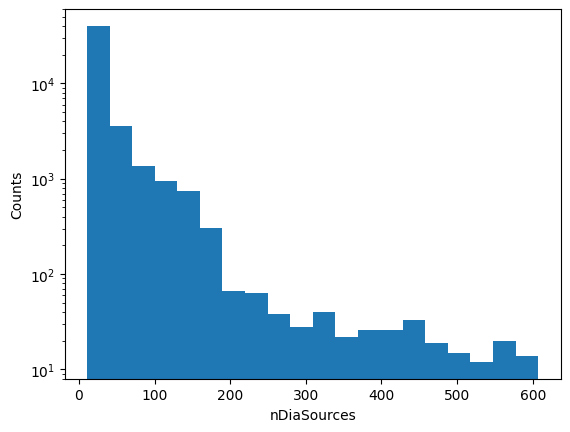

In [8]:
plt.hist(df_clean["nDiaSources"], bins=20)
plt.yscale("log")
plt.xlabel("nDiaSources")
plt.ylabel("Counts")